In [1]:
import sys
sys.path.append('..')

import tomodpdt

import numpy as np
import time
import matplotlib.pyplot as plt
import deeplay as dl

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

In [2]:
DEV = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Using device:', DEV)

Using device: cuda


In [3]:
data = np.load('D:/NewDataMonica/data_full_09_10_2024_HEK_03_04_us4.npz', allow_pickle=True)
#data = np.load('/home/mph-workstation/simon/2024-03-15/data_full_09_10_2024_HEK_03_04_us4.npz', allow_pickle=True)

In [4]:
data.keys()

KeysView(NpzFile 'D:/NewDataMonica/data_full_09_10_2024_HEK_03_04_us4.npz' with keys: E, q, t, n)

In [5]:
data['E'].shape, data['q'].shape, data['t'].shape

((3990, 174, 200), (3990, 4), (3990, 3))

In [6]:
index_min = 0
index_max = 200

EM = data['E'][index_min:index_max]
Q_GT = data['q'][index_min:index_max]
T_GT = data['t'][index_min:index_max]
dRI_GT = data['n'] - 1.33
print(EM.shape)

(200, 174, 200)


In [7]:
dRI_GT.transpose(1, 2, 0).shape

(174, 200, 150)

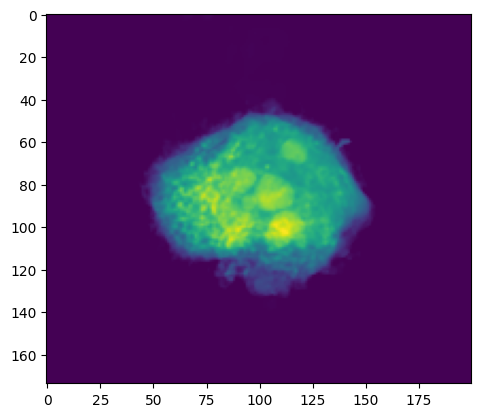

In [8]:
plt.imshow(dRI_GT.transpose(1, 2, 0).sum(axis=-1))

In [9]:
#N = 150


#EM_crop = np.zeros((200, N, N), dtype=np.complex64)
#EM_crop[:] = EM[:, 174//2-N//2:174//2+N//2, 100-N//2:100+N//2]

EM_crop = EM

#dRI_GT_crop = np.zeros((N, N, N), dtype=np.float32)
#dRI_GT_crop[:] = dRI_GT.transpose(1, 2, 0)[174//2-N//2:174//2+N//2,100-N//2:100+N//2]
dRI_GT_crop = dRI_GT.transpose(1, 2, 0)

In [10]:
nx, ny, nz = dRI_GT_crop.shape
print('Crop shape:', EM_crop.shape, dRI_GT_crop.shape)

Crop shape: (200, 174, 200) (174, 200, 150)


In [11]:
dx, dy, dz = 200e-9, 200e-9, 200e-9
kx, ky = torch.meshgrid([torch.fft.fftfreq(nx, d=dx) * 2 * np.pi, torch.fft.fftfreq(ny, d=dy) * 2 * np.pi], indexing='ij')
wavelength = 640e-9
n0 = 1.33
k0 = 2 * np.pi / wavelength
se = (k0 * n0)**2 - kx**2 - ky**2
kz = torch.sqrt(se * (se>0)).cuda()

def forward_model(dRI, q, t, K):

    bs = q.shape[0]
    E = torch.ones((bs, nx, ny), dtype=torch.complex64, device=DEV)
    t_xy = torch.zeros_like(t)
    t_xy[:, :2] = t[:, :2]
    dRI_b = tomographic_model.apply_rotation_batch(dRI, q, t_xy)
    
    for i in range(nz):

        E = torch.fft.ifft2(torch.fft.fft2(E, dim=(1, 2)) * K, dim=(1, 2))
        E = E * torch.exp(1j * dRI_b[...,i] * k0 * dz)

    E = torch.fft.ifft2(torch.fft.fft2(E, dim=(1, 2)) * torch.exp(1j * kz * t[:, None, None, 2] * dz), dim=(1, 2)) 

    return E * torch.exp(-1j*(nz*dz*k0*n0 + t[:, None, None, 2]*dz*k0*n0))

def loss_smooth(q, λ1, λ2):

    qd = torch.diff(q, axis=0)
    qdd = torch.diff(qd, axis=0)
    
    return (λ1 * torch.sum(torch.square(qd)) + λ2 * torch.sum(torch.square(qdd))) / q.shape[0]

def loss_TV(a):

    ax = torch.diff(a, axis=0, append=a[-1, None])
    ay = torch.diff(a, axis=1, append=a[:, -1, None])
    az = torch.diff(a, axis=2, append=a[:, :, -1, None])
    beta = 1e-10
    
    return torch.sqrt(ax**2 + ay**2 + az**2 + beta).sum() / a.numel()
    

def loss_data(E, EM):

    return torch.square(torch.abs(E - EM)).mean()



In [12]:
nz

150

In [13]:
from tomodpdt.imaging_modality_torch import setup_optics, imaging_model

# Setup the optics
optics_settings = setup_optics(
        shape=(nx, ny, nz),
        padding_xy=0, 
        microscopy_regime='Brightfield', 
        NA=1.15, 
        wavelength=640e-9, 
        resolution=200e-9, 
        magnification=1, 
        return_field=True)

# Generate the imaging model
brightfield_model = imaging_model(optics_setup=optics_settings)

In [14]:
# Create the tomographic_model
tomographic_model = tomodpdt.Tomography(
    volume_size=(nx, ny, nz), # The size of the volume
    initial_volume='zeros', # 'refraction' since we are optimizing the refractive index
    rotation_optim_case='quaternion', # 'basis' or 'quaternion', 'basis' is smoother
    imaging_model=brightfield_model, # The imaging model,
    )

In [15]:
from skimage.restoration import unwrap_phase
from scipy.signal import find_peaks

In [16]:
PU = [unwrap_phase(np.angle(E)) for E in EM_crop]

In [17]:
def calc_cc(a, b):
    return np.abs(np.fft.ifft2(np.fft.fft2(a) * np.fft.fft2(b))).max()

In [18]:
cc = []
for i in range(0, 200):
    cc.append(calc_cc(PU[0], PU[i]))
cc = np.array(cc)

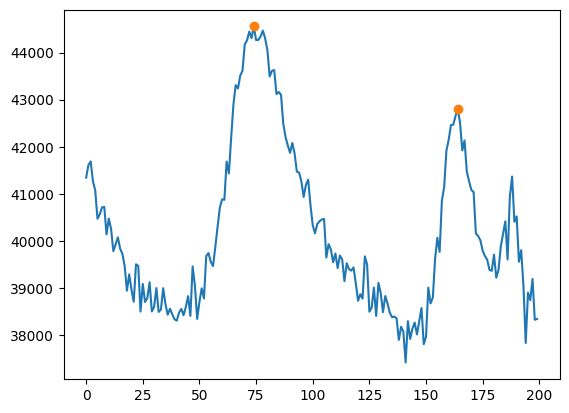

In [19]:
pks = find_peaks(cc, width=10)[0]

plt.plot(cc)
plt.plot(pks, cc[pks], 'o')

In [20]:
pks

array([ 74, 164], dtype=int64)

In [21]:
PU = [unwrap_phase(np.angle(E)) for E in EM_crop]

def calc_cc(a, b):
    return np.abs(np.fft.ifft2(np.fft.fft2(a) * np.fft.fft2(b))).max()

cc = []
for i in range(0, 200):
    cc.append(calc_cc(PU[0], PU[i]))
cc = np.array(cc)

pks = find_peaks(cc, width=10)[0]

th = np.array([0.])
for i, pk in enumerate(pks):
    th = np.r_[th, np.linspace(i*np.pi, (i+1)*np.pi, (pks[i] - pks[i-1]) + 1 if i>0 else pks[i])[1:]]
    
th = np.r_[th, np.linspace((i+1)*np.pi, (i+1)*np.pi + np.pi * ((200 - pks[i]) / (pks[i] - pks[i-1])) , 200 - pks[i] + 1)[1:]]


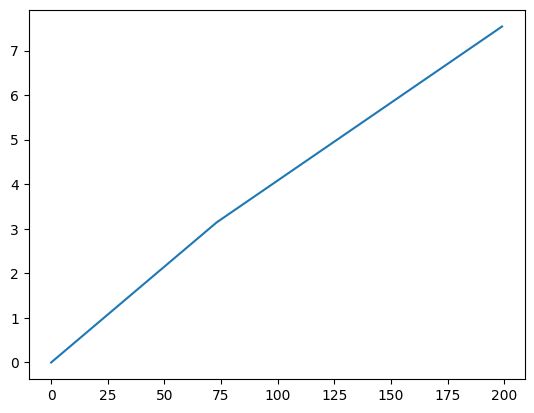

In [22]:
plt.plot(th)

In [23]:
2.3*np.pi

7.225663103256523

In [24]:
Q_GT_new = np.zeros_like(Q_GT)
Q_GT_new[:, 0] = Q_GT[:, 0]
Q_GT_new[:, 1] = -Q_GT[:, 2]
Q_GT_new[:, 2] = -Q_GT[:, 3]
Q_GT_new[:, 3] = -Q_GT[:, 1]

T_GT_new = np.zeros_like(T_GT)
T_GT_new[:, 0] = T_GT[:, 1] / dx
T_GT_new[:, 1] = T_GT[:, 2] / dx
T_GT_new[:, 2] = (T_GT[:, 0] - 150 * dx / 2) / dx

#th = np.linspace(0, 2.3 * np.pi, 200)
Q_start = np.zeros_like(Q_GT_new)
Q_start[:, 0] = np.cos(-th/2)
Q_start[:, 2] = np.sin(-th/2)

T_start = np.zeros_like(T_GT_new)
T_start[:, 2] = - 40.

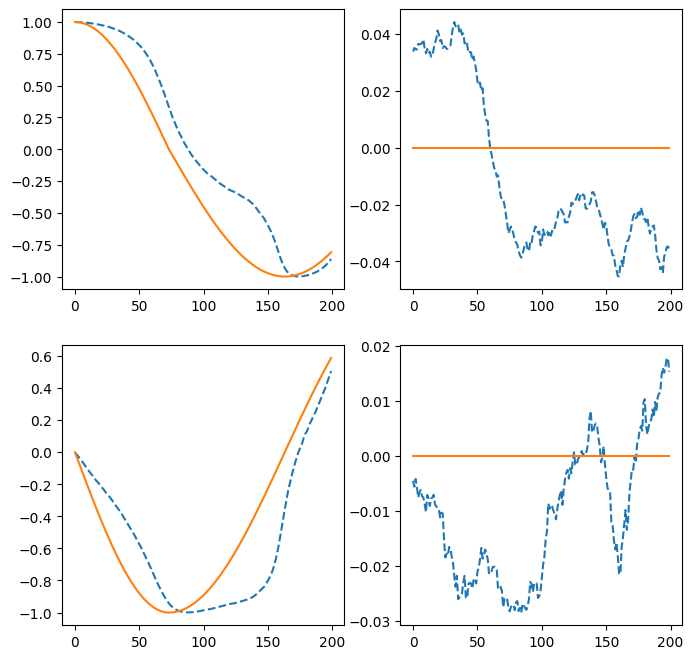

In [25]:
plt.figure(figsize=(8, 8))
for i in range(4):
    plt.subplot(2, 2, i+1) 
    plt.plot(Q_GT_new[:,i], '--')
    plt.plot(Q_start[:,i], '-')

In [26]:
E_test = np.zeros((200, nx, ny), dtype=np.complex64)
bs = 10
K = torch.exp(1j * kz * dz)
dRI_test = torch.Tensor(dRI_GT_crop).to(device=DEV)
Q_test = torch.Tensor(Q_GT_new).to(device=DEV)
T_test = torch.Tensor(T_GT_new).to(device=DEV)

for i in range(200//bs):

    slb = slice(i*bs, (i+1)*bs)
    E_test[slb] = forward_model(dRI_test, Q_test[slb], T_test[slb], K).cpu().numpy()

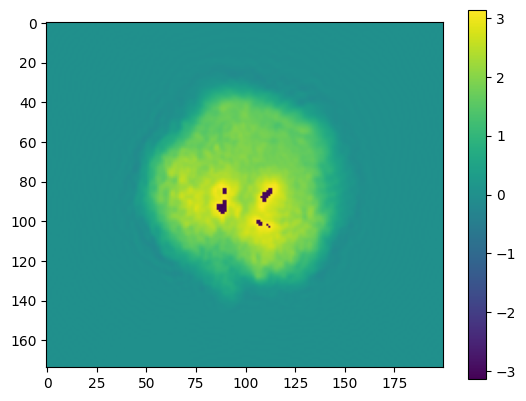

In [27]:
plt.imshow(np.angle(E_test[0]))
plt.colorbar()

In [28]:
maxiter = 250
lr_dRI = 5e-5
lr_q = 3e-6
lr_t = 1e-4
λ_TV = 1e-1
λ1_q = 5e1 
λ2_q = 5e1 

lr_dRI = 5.
lr_q = 1e0
lr_t = 1e3
λ_TV = 7e0
λ1_q = 5e0
λ2_q = 5e0 

#dRI = torch.tensor(dRI_GT_crop, dtype=torch.float32, requires_grad=True, device=DEV)
#Q = torch.tensor(Q_GT_new, requires_grad=True, device=DEV)
#T = torch.tensor(T_GT_new, requires_grad=True, device=DEV)
dRI = torch.zeros((nx, ny, nz), dtype=torch.float32, requires_grad=True, device=DEV)

Q = torch.tensor(Q_start, dtype=torch.float32, requires_grad=True, device=DEV)
T = torch.tensor(T_start, dtype=torch.float32, requires_grad=True, device=DEV)

EM_trch = torch.tensor(EM_crop * np.exp(-1j * np.angle(EM_crop[:, :20, :20]).mean(axis=(1,2), keepdims=True)), requires_grad=False, device=DEV) 
errors = []

In [29]:
1e-1 * dRI.numel()

522000.0

In [30]:
i = 0
idx = np.random.permutation(200)
idx_b = idx[i * bs: (i+1) * bs]
Eb = forward_model(dRI, Q[idx_b], T[idx_b], K)
err_loc = loss_data(Eb, EM_trch[idx_b]) + λ_TV * loss_TV(dRI) + loss_smooth(Q, λ1_q, λ2_q)
err_loc.backward()
loss_data(Eb, EM_trch[idx_b]), λ_TV * loss_TV(dRI), loss_smooth(Q, λ1_q, λ2_q)

(tensor(0.5443, device='cuda:0', grad_fn=<MeanBackward0>),
 tensor(7.0000e-05, device='cuda:0', grad_fn=<MulBackward0>),
 tensor(0.0018, device='cuda:0', grad_fn=<DivBackward0>))

In [31]:
Eb.shape

torch.Size([10, 174, 200])

In [32]:
# Create the tomographic_model
tomographic_model = tomodpdt.Tomography(
    volume_size=(nx, ny, nz), # The size of the volume
    initial_volume='zeros', # 'refraction' since we are optimizing the refractive index
    rotation_optim_case='quaternion', # 'basis' or 'quaternion', 'basis' is smoother
    imaging_model=brightfield_model, # The imaging model,
    )

In [33]:
projections = torch.stack([EM_trch.real, EM_trch.imag], axis=1)
tomographic_model.initialize_parameters(projections, normalize=False, max_epochs=100)

c:\Users\Fredrik\miniconda3\envs\deeplaydev\Lib\site-packages\lightning\pytorch\trainer\connectors\logger_connector\logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
c:\Users\Fredrik\miniconda3\envs\deeplaydev\Lib\site-packages\lightning\pytorch\trainer\configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.

  | Name                | Type                 | Params | Mode 
---------------------------------------------------------------------
0 | encoder             | Sequential           | 80.1 K | train
1 | fc_mu               | MultiLayerPerceptron | 281 K 

Epoch 99: 100%|██████████| 7/7 [00:00<00:00, 15.55it/s, v_num=1337, train_rec_loss_step=0.0738, train_KL_step=49.00, train_total_loss_step=0.0743, train_rec_loss_epoch=0.0767, train_KL_epoch=184.0, train_total_loss_epoch=0.0785] 


In [34]:
plotter = tomodpdt.plotting.TomoPlotter(tomographic_model)

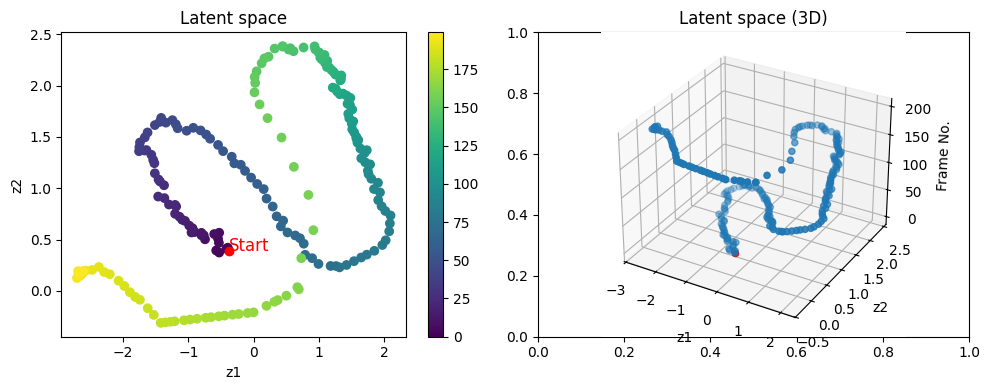

In [35]:
plotter.plot_latent_space()

In [36]:
tomographic_model.rotation_params = torch.nn.Parameter(torch.tensor(Q_start[:len(tomographic_model.rotation_params)]))
tomographic_model.translation_params = torch.nn.Parameter(torch.tensor(T_start[:len(tomographic_model.rotation_params)]))

tomographic_model.move_all_to_device(DEV)

In [37]:


for it in range(maxiter):

    idx = np.random.permutation(len(tomographic_model.rotation_params))
    err = 0

    for i in range(len(tomographic_model.rotation_params)//bs):

        idx_b = idx[i * bs: (i+1) * bs]

        # Forward model
        Eb = tomographic_model.forward(idx=idx_b)
        Eb = Eb[:, 0] + 1j * Eb[:, 1]

        err_loc = loss_data(Eb, EM_trch[idx_b]) + λ_TV * loss_TV(tomographic_model.volume) + loss_smooth(tomographic_model.rotation_params, λ1_q, λ2_q)
        err_loc.backward()
        err += err_loc.item()

        with torch.no_grad():

            torch.clip(tomographic_model.volume - lr_dRI * tomographic_model.volume.grad, 0., 1., out=tomographic_model.volume)

            tomographic_model.rotation_params -= lr_q * tomographic_model.rotation_params.grad
            tomographic_model.rotation_params[:] = tomographic_model.rotation_params / torch.norm(tomographic_model.rotation_params, dim=1, keepdim=True)
            tomographic_model.translation_params -= lr_t * tomographic_model.translation_params.grad

            #print(torch.abs(dRI.grad).mean(), torch.abs(Q.grad).mean(), torch.abs(T.grad[:, :2]).mean(), torch.abs(T.grad[:, 2]).mean())

            tomographic_model.volume.grad = None
            tomographic_model.rotation_params.grad = None
            tomographic_model.translation_params.grad = None
     
        

    #err_q = λ_q * loss_smooth(Q)
    #err_q.backward()
    #err += err_q
    
    #with torch.no_grad():

    #    Q -= lr_q * Q.grad
    #    Q[:] = Q / torch.norm(Q, dim=1, keepdim=True)
    #    T -= lr_t * T.grad
        
    #    print(torch.abs(Q.grad).mean(), torch.abs(T.grad[:, :2]).mean(), torch.abs(T.grad[:, 2]).mean())

    #    Q.grad = None
    #    T.grad = None
    
    print(it, err)
    errors.append(err)
    

    

        
#432509.2500

0 6.596321925520897
1 2.2421986386179924
2 1.398629106581211
3 1.2172720804810524
4 1.1273687221109867
5 1.0677300244569778
6 1.0178382582962513
7 0.9913750290870667
8 0.9777602255344391
9 0.956033818423748
10 0.9459666274487972
11 0.9303997866809368
12 0.929084699600935
13 0.9116913042962551
14 0.9021008759737015
15 0.8929742574691772
16 0.890107873827219
17 0.8760910555720329
18 0.8755400516092777
19 0.8709159307181835
20 0.8619915321469307
21 0.858003281056881
22 0.8529148921370506
23 0.846829392015934
24 0.8430953733623028
25 0.8390550389885902
26 0.8354334533214569
27 0.8322161510586739
28 0.8300420604646206
29 0.8293020874261856
30 0.8257048949599266
31 0.8214074857532978
32 0.8212607800960541
33 0.8191364482045174
34 0.8171782419085503
35 0.8147552199661732
36 0.8123444840312004
37 0.8107601180672646
38 0.8144834265112877
39 0.8088941425085068


KeyboardInterrupt: 

In [38]:
dRI = tomographic_model.volume
Q = tomographic_model.rotation_params
T = tomographic_model.translation_params

In [39]:
Eb.shape

torch.Size([10, 174, 200])

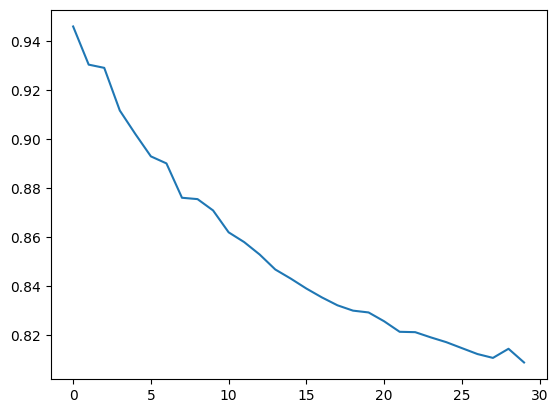

In [40]:
plt.plot(errors[10:])

In [41]:
#import stackview
#stackview.curtain(dRI.cpu().detach().numpy(), dRI_GT_crop)

In [42]:
xs, ys, zs = dRI.shape

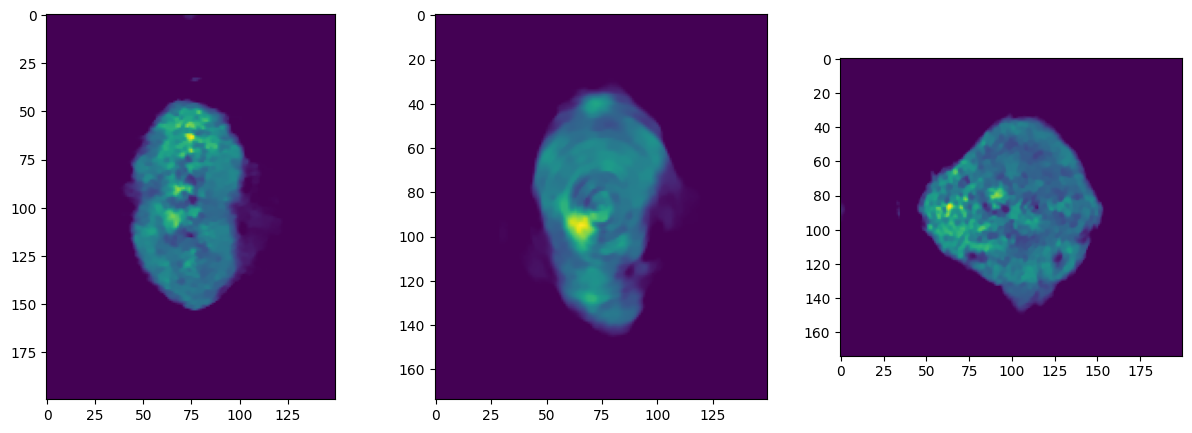

In [43]:
plt.figure(figsize=(15, 5))
plt.subplot(131)
plt.imshow(dRI.cpu().detach().numpy()[xs//2])

plt.subplot(132)
plt.imshow(dRI.cpu().detach().numpy()[:, ys//2])

plt.subplot(133)
plt.imshow(dRI.cpu().detach().numpy()[:, :, zs//2])


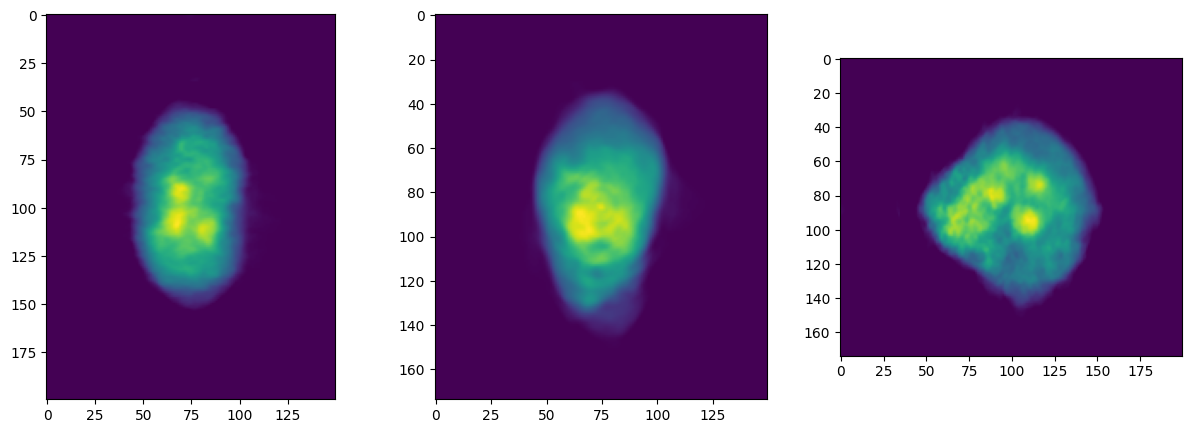

In [44]:
plt.figure(figsize=(15, 5))
plt.subplot(131)
plt.imshow(dRI.cpu().detach().numpy().sum(axis=0))

plt.subplot(132)
plt.imshow(dRI.cpu().detach().numpy().sum(axis=1))

plt.subplot(133)
plt.imshow(dRI.cpu().detach().numpy().sum(axis=2))


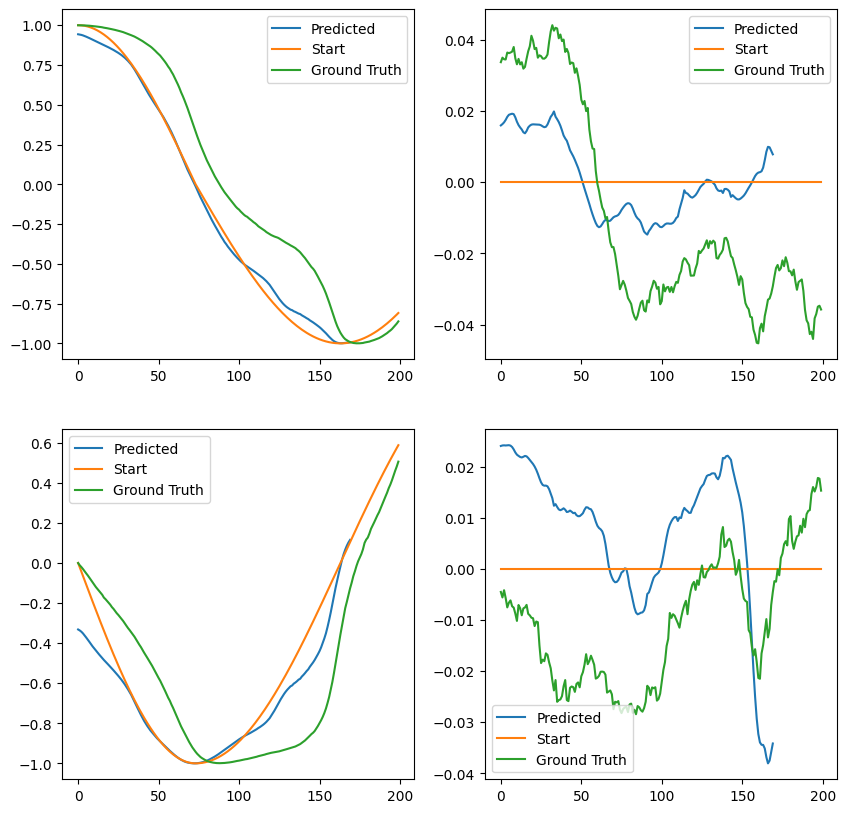

In [49]:
plt.figure(figsize=(10, 10))
for i in range(4):
    plt.subplot(2, 2, 1+i)
    plt.plot(Q.cpu().detach().numpy()[:, i], label='Predicted')
    plt.plot(Q_start[:, i], label='Start')
    plt.plot(Q_GT_new[:, i], label='Ground Truth')
    plt.legend()

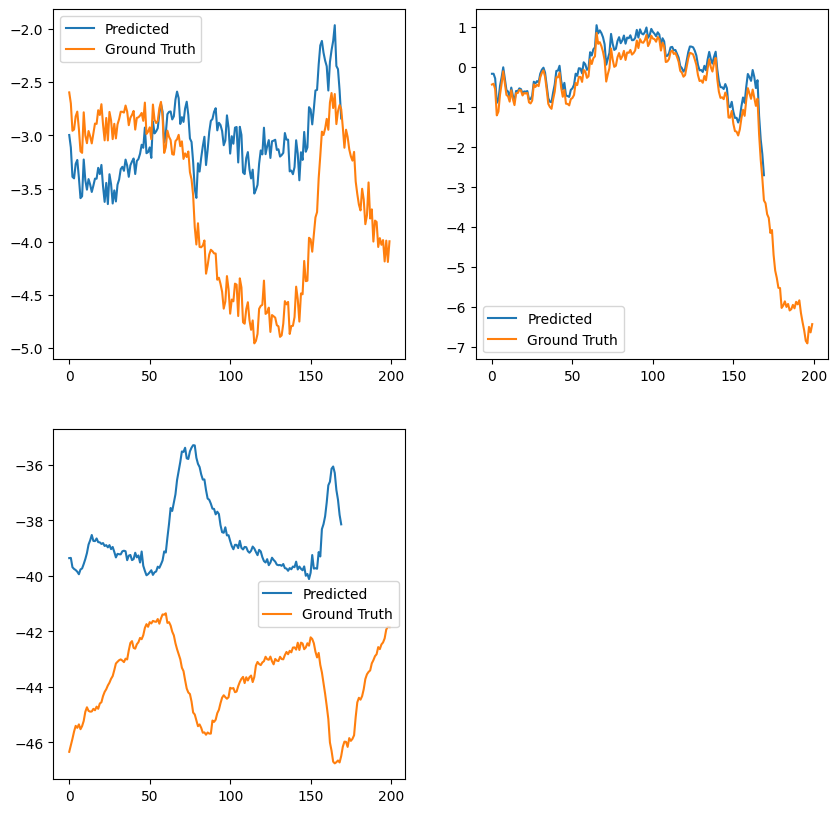

In [50]:
plt.figure(figsize=(10, 10))
for i in range(3):
    plt.subplot(2, 2, 1+i)
    plt.plot(T.cpu().detach().numpy()[:,i], label='Predicted')
    plt.plot(T_GT_new[:,i], label='Ground Truth')
    plt.legend()



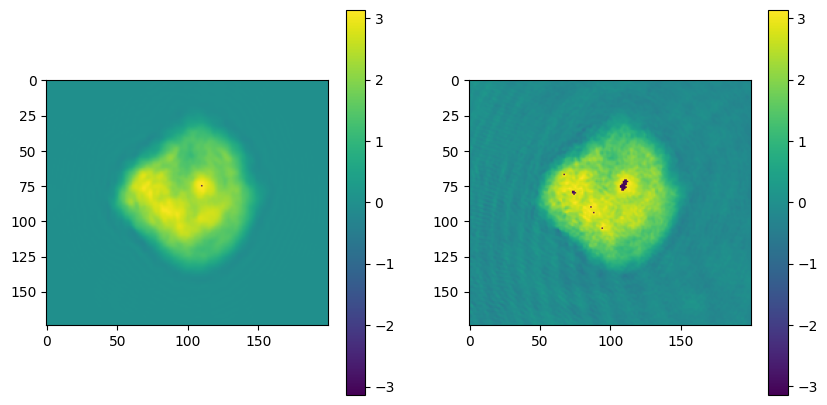

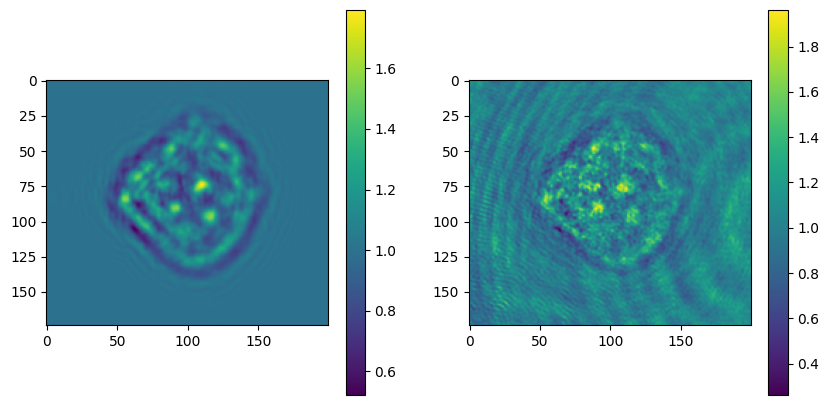

In [47]:
plt.figure(figsize=(10, 5))
plt.subplot(121)
plt.imshow(np.angle(Eb.cpu().detach().numpy()[0]))
plt.colorbar()
plt.subplot(122)
plt.imshow(np.angle(EM_trch.cpu().detach().numpy()[idx_b][0]))
plt.colorbar()

plt.figure(figsize=(10, 5))
plt.subplot(121)
plt.imshow(np.abs(Eb.cpu().detach().numpy()[0]))
plt.colorbar()
plt.subplot(122)
plt.imshow(np.abs(EM_trch.cpu().detach().numpy()[idx_b][0]))
plt.colorbar()